## 11. Does the parcellation choice actually mater?

In [10]:
import os
import glob
import pickle
import re
from collections import defaultdict
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
# Root folder — one sub-directory per subject, e.g. data/NF/002GNV/
DATA_ROOT = "../../../Data/"

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

In [12]:
def discover_subjects(data_root):
    """Return sorted list of subject IDs (= sub-folder names) in data_root."""
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )

# --- Discover and load all subjects ---
subject_ids = discover_subjects("../../../Data/")
print(f"Subjects found: {subject_ids}\n")

Subjects found: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']



In [13]:
def compute_yeo7_metrics(fc, yeo_labels):
    # Step 1 – restrict to cortical parcels (Yeo 1-7)
    cortical_mask = (yeo_labels >= 1) & (yeo_labels <= 7)
    fc_cx  = np.array(fc[np.ix_(cortical_mask, cortical_mask)], dtype=float, copy=True)
    yeo_cx = yeo_labels[cortical_mask].astype(int)

    # Step 2 – Fisher z-transform, remove self-connections
    fc_cx = np.clip(fc_cx, -0.999999, 0.999999)
    fc_z  = np.arctanh(fc_cx)
    np.fill_diagonal(fc_z, np.nan)

    # Step 3 – per-network seg/int  (your existing code, unchanged)
    K = 7
    segregation = np.full(K, np.nan)
    integration = np.full(K, np.nan)

    for k in range(1, K + 1):
        mask_k     = (yeo_cx == k)
        mask_other = (yeo_cx != k)
        if mask_k.sum() >= 2:
            within = fc_z[np.ix_(mask_k, mask_k)].copy()
            np.fill_diagonal(within, np.nan)
            segregation[k - 1] = np.nanmean(within)
        if mask_k.sum() > 0 and mask_other.sum() > 0:
            integration[k - 1] = np.nanmean(fc_z[np.ix_(mask_k, mask_other)])

    normalized_segregation = (segregation - integration) / (segregation + integration)

    # ── NEW: Step 4 – participation coefficient & within-module degree z-score ──
    N = fc_z.shape[0]
    fc_work = np.nan_to_num(fc_z, nan=0.0)  # treat NaN diagonal as 0 for strength sums

    # Participation coefficient
    pc = np.full(N, np.nan)
    for i in range(N):
        k_i = np.sum(fc_work[i, :])
        if k_i == 0:
            continue
        sum_sq = sum((np.sum(fc_work[i, yeo_cx == s]) / k_i) ** 2 for s in range(1, 8))
        pc[i] = 1.0 - sum_sq

    # Participation coefficient (positive weights only)
    fc_pos = np.where(fc_z > 0, fc_z, 0.0)
    fc_pos = np.nan_to_num(fc_pos, nan=0.0)

    pc_parcel = np.full(N, np.nan)
    for i in range(N):
        k_i = np.sum(fc_pos[i, :])
        if k_i <= 0:
            continue

        sum_sq = 0.0
        for s in range(1, K + 1):
            k_is = np.sum(fc_pos[i, yeo_cx == s])
            sum_sq += (k_is / k_i) ** 2

        pc_parcel[i] = 1.0 - sum_sq

    # ── END NEW ──

    return segregation, integration, normalized_segregation, pc

In [14]:
# =========================================================================
# Parcellation Sensitivity Analysis
# Effect of parcellation resolution on Spearman trend significance
# =========================================================================
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

PARCELLATIONS = {
    "r100": (119, "_100"),
    "r200": (219, "_200"),
    "r400": (419, "_400"),
    "r800": (819, "_800"),
}


In [15]:
def load_subject_parcellation(data_root, subject_id, suffix):
    """
    Same as load_subject but loads FC matrices for a given parcellation suffix
    (_100, _200, _400, _800) and the matching Yeo labels.
    """
    subj_dir = os.path.join(data_root, subject_id, "NF")

    utils_path = os.path.join(subj_dir, f"{subject_id}_utils.pkl")
    with open(utils_path, "rb") as f:
        utils = pickle.load(f)

    # e.g. suffix "_200" → key "r200"
    res_key = "r" + suffix.strip("_")
    yeo_labels = np.array(utils["yeo7"][res_key]["yeoROIs"]).astype(int).ravel()

    fc_files = sorted(glob.glob(os.path.join(subj_dir, f"{subject_id}_V*_FC_Schaefer.pkl")))

    sessions = {}
    for fc_path in fc_files:
        session_id = os.path.basename(fc_path).split("_")[1]
        with open(fc_path, "rb") as f:
            data = pickle.load(f)

        run_map = {}
        for key, fc in data["FC_FD"].items():
            if not key.endswith(suffix):
                continue
            m = re.match(r"V\d+_Run(\d+)(?:_(Transfer|NoFeedback))?" + suffix, key)
            if m is None:
                continue
            run_key   = f"Run{m.group(1)}"
            condition = m.group(2) if m.group(2) else "Feedback"
            run_map[run_key] = {"condition": condition, "FC": fc}

        sessions[session_id] = run_map

    return sessions, yeo_labels

In [16]:
def compute_group_session_avg(data_root, subject_ids, suffix, yeo_names):
    """
    Load all subjects for a given parcellation suffix, compute metrics,
    and return group-average session arrays (n_sessions × 7).
    """
    all_sessions_set = set()
    per_subject = {}

    for sid in subject_ids:
        sessions, yeo_labels = load_subject_parcellation(data_root, sid, suffix)

        # compute metrics for every run
        rows = []
        for sess_id, sess_runs in sessions.items():
            all_sessions_set.add(sess_id)
            for run_key in sorted(sess_runs.keys(), key=lambda x: int(x.replace("Run", ""))):
                rd = sess_runs[run_key]
                seg, intg, normseg, _ = compute_yeo7_metrics(rd["FC"], yeo_labels)
                rows.append({
                    "session":               sess_id,
                    "segregation":           seg,
                    "integration":           intg,
                    "normalized_segregation": normseg,
                })

        # average runs within each session
        all_sessions = sorted(all_sessions_set)
        session_groups = defaultdict(list)
        for r in rows:
            session_groups[r["session"]].append(r)

        seg_sv, int_sv, normseg_sv = [], [], []
        for sess in all_sessions:
            sr = session_groups.get(sess, [])
            if sr:
                seg_sv.append(np.nanmean(np.vstack([r["segregation"] for r in sr]), axis=0))
                int_sv.append(np.nanmean(np.vstack([r["integration"] for r in sr]), axis=0))
                normseg_sv.append(np.nanmean(np.vstack([r["normalized_segregation"] for r in sr]), axis=0))
            else:
                seg_sv.append(np.full(7, np.nan))
                int_sv.append(np.full(7, np.nan))
                normseg_sv.append(np.full(7, np.nan))

        per_subject[sid] = (np.vstack(seg_sv), np.vstack(int_sv), np.vstack(normseg_sv))

    all_sessions = sorted(all_sessions_set)
    seg_group     = np.nanmean(np.stack([v[0] for v in per_subject.values()]), axis=0)
    int_group     = np.nanmean(np.stack([v[1] for v in per_subject.values()]), axis=0)
    normseg_group = np.nanmean(np.stack([v[2] for v in per_subject.values()]), axis=0)

    return all_sessions, seg_group, int_group, normseg_group

In [17]:
def spearman_fdr(x, seg_group, int_group, normseg_group, yeo_names):
    """Run Spearman + FDR correction, return dict of results keyed by network."""
    raw_rho, raw_p = [], []
    for i in range(7):
        rho_s, p_s = spearmanr(x, seg_group[:, i])
        rho_i, p_i = spearmanr(x, int_group[:, i])
        rho_n, p_n = spearmanr(x, normseg_group[:, i])
        raw_rho.append((rho_s, rho_i, rho_n))
        raw_p.extend([p_s, p_i, p_n])   # 21 p-values

    _, p_adj, _, _ = multipletests(raw_p, method="fdr_bh")

    results = {}
    for i, net in enumerate(yeo_names):
        results[net] = {
            "rho_seg":    raw_rho[i][0], "p_seg":    p_adj[i*3],
            "rho_int":    raw_rho[i][1], "p_int":    p_adj[i*3+1],
            "rho_normseg": raw_rho[i][2], "p_normseg": p_adj[i*3+2],
        }
    return results


In [18]:
# --- Run across all parcellations ---
parc_results = {}
for name, (size, suffix) in PARCELLATIONS.items():
    print(f"Computing {name} ({size}×{size})...")
    all_sessions, seg_g, int_g, normseg_g = compute_group_session_avg(
        DATA_ROOT, subject_ids, suffix, YEO_NAMES)
    x = np.arange(len(all_sessions))
    parc_results[name] = spearman_fdr(x, seg_g, int_g, normseg_g, YEO_NAMES)

print("Done.")


Computing r100 (119×119)...


Computing r200 (219×219)...
Computing r400 (419×419)...
Computing r800 (819×819)...
Done.


In [19]:
# --- Print comparison table ---
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

parc_names = list(PARCELLATIONS.keys())   # r100, r200, r400, r800
metrics    = [("seg", "Segregation"), ("int", "Integration"), ("normseg", "Norm.Seg")]

for metric_key, metric_label in metrics:
    print(f"\n{'='*70}")
    print(f"  {metric_label} — FDR-corrected Spearman p-value across parcellations")
    print(f"{'='*70}")
    header = f"{'Network':<22}" + "".join(f"{p:>10}" for p in parc_names)
    print(header)
    print("-" * len(header))
    for net in YEO_NAMES:
        row = f"{net:<22}"
        for p_name in parc_names:
            r   = parc_results[p_name][net]
            rho = r[f"rho_{metric_key}"]
            p   = r[f"p_{metric_key}"]
            row += f"  {rho:+.2f}{sig_stars(p):>3}"
        print(row)

print("\nFDR-corrected (Benjamini-Hochberg)   * p<0.05  ** p<0.01  *** p<0.001  ns = not significant")



  Segregation — FDR-corrected Spearman p-value across parcellations
Network                     r100      r200      r400      r800
--------------------------------------------------------------
Visual                  -0.72 **  -0.63  *  -0.71 **  -0.66  *
Somatomotor             -0.52 ns  -0.54  *  -0.47 ns  -0.44 ns
Dorsal Attention        -0.78 **  -0.77 **  -0.80 **  -0.78 **
Ventral Attention       -0.74 **  -0.79 **  -0.75 **  -0.70  *
Limbic                  +0.01 ns  +0.13 ns  +0.19 ns  +0.15 ns
Frontoparietal          -0.53  *  -0.65  *  -0.69  *  -0.61  *
Default                 -0.55  *  -0.58  *  -0.53 ns  -0.42 ns

  Integration — FDR-corrected Spearman p-value across parcellations
Network                     r100      r200      r400      r800
--------------------------------------------------------------
Visual                  -0.62  *  -0.60  *  -0.57  *  -0.55  *
Somatomotor             -0.68 **  -0.67  *  -0.65  *  -0.55  *
Dorsal Attention        -0.68 **  -0.69 ** 

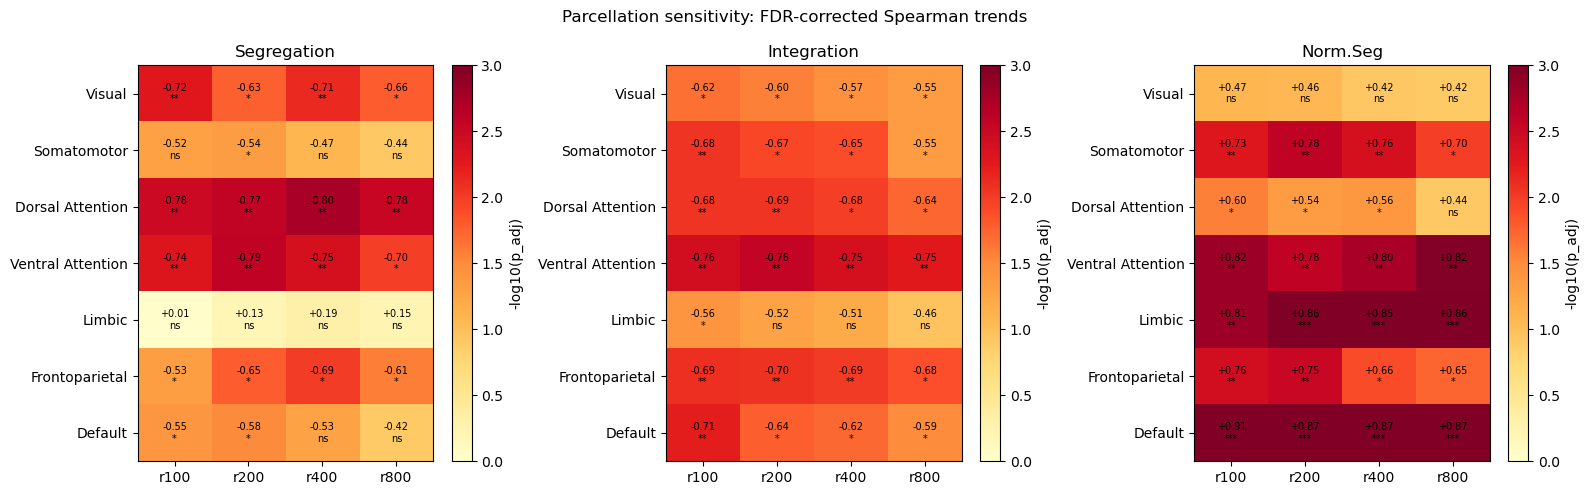

In [20]:
# --- Heatmap of -log10(p_adj) per parcellation ---
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric_key, metric_label) in zip(axes, metrics):
    matrix = np.zeros((7, 4))   # networks × parcellations
    for j, p_name in enumerate(parc_names):
        for i, net in enumerate(YEO_NAMES):
            p = parc_results[p_name][net][f"p_{metric_key}"]
            matrix[i, j] = -np.log10(p + 1e-10)

    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=-np.log10(0.001))
    ax.set_xticks(range(4))
    ax.set_xticklabels(parc_names)
    ax.set_yticks(range(7))
    ax.set_yticklabels(YEO_NAMES)
    ax.set_title(metric_label)

    # Annotate cells with rho + stars
    for j, p_name in enumerate(parc_names):
        for i, net in enumerate(YEO_NAMES):
            r   = parc_results[p_name][net]
            rho = r[f"rho_{metric_key}"]
            p   = r[f"p_{metric_key}"]
            ax.text(j, i, f"{rho:+.2f}\n{sig_stars(p)}",
                    ha="center", va="center", fontsize=7)

    plt.colorbar(im, ax=ax, label="-log10(p_adj)")

fig.suptitle("Parcellation sensitivity: FDR-corrected Spearman trends", fontsize=12)
plt.tight_layout()
plt.show()


In [21]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# ════════════════════════════════════════════════════════════════
# STEP 1 — build long dataframe of ALL runs (no averaging)
# ════════════════════════════════════════════════════════════════
def build_long_df(data_root, subject_ids, suffix, yeo_names):
    """
    Returns a long-format dataframe with one row per
    subject × session × run × network.
    """
    rows = []
    for sid in subject_ids:
        sessions, yeo_labels = load_subject_parcellation(data_root, sid, suffix)

        for sess_id, sess_runs in sessions.items():
            sess_num = int(str(sess_id).replace("V", ""))  # V01→1, V02→2 …

            for run_key in sorted(sess_runs.keys(),
                                    key=lambda x: int(x.replace("Run", ""))):
                rd = sess_runs[run_key]
                seg, intg, normseg, _ = compute_yeo7_metrics(rd["FC"], yeo_labels)

                # one row per network
                for net_i, net_name in enumerate(yeo_names):
                    rows.append({
                        "subject":               sid,
                        "session":               sess_id,
                        "session_num":           sess_num,
                        "run":                   run_key,
                        "network":               net_i + 1,
                        "network_name":          net_name,
                        "segregation":           seg[net_i],
                        "integration":           intg[net_i],
                        "normalized_segregation": normseg[net_i],
                    })

    return pd.DataFrame(rows)


# ════════════════════════════════════════════════════════════════
# STEP 2 — fit LME per network × metric, collect betas + p-values
# ════════════════════════════════════════════════════════════════
def lme_fdr(df_long, yeo_names,
            metrics=("segregation", "integration", "normalized_segregation")):
    """
    Fit LME (random intercept per subject) for each network × metric.
    Returns a dataframe with beta, raw p, and FDR-corrected p.
    """
    records = []

    for metric in metrics:
        for net_i, net_name in enumerate(yeo_names):
            net_df = df_long[df_long["network"] == net_i + 1].dropna(subset=[metric])

            if net_df.empty:
                continue

            lme = smf.mixedlm(
                f"{metric} ~ session_num",
                data=net_df,
                groups=net_df["subject"]
            ).fit(reml=True, method="lbfgs")

            records.append({
                "metric":    metric,
                "network":   net_i + 1,
                "net_name":  net_name,
                "beta":      lme.params["session_num"],
                "p_raw":     lme.pvalues["session_num"],
            })

    stats_df = pd.DataFrame(records)

    # FDR correction across all networks × metrics at once
    _, p_corr, _, _ = multipletests(stats_df["p_raw"], method="fdr_bh")
    stats_df["p_corr"]      = p_corr
    stats_df["beta_session"] = stats_df["beta"]  # alias for plot function

    return stats_df


# ════════════════════════════════════════════════════════════════
# STEP 3 — run across parcellations
# ════════════════════════════════════════════════════════════════
parc_results = {}

for name, (size, suffix) in PARCELLATIONS.items():
    print(f"Computing {name} ({size}×{size})...")

    df_long = build_long_df(DATA_ROOT, subject_ids, suffix, YEO_NAMES)
    stats_df = lme_fdr(df_long, YEO_NAMES)

    parc_results[name] = {
        "df_long":  df_long,
        "stats_df": stats_df,
    }

print("Done.")

Computing r100 (119×119)...


c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

Computing r200 (219×219)...


c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

Computing r400 (419×419)...


c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

Computing r800 (819×819)...


c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarni

Done.


c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

In [22]:
# adapted key lookup for new parc_results structure
def get_lme_result(parc_results, parc_name, metric, net_id):
    stats_df = parc_results[parc_name]["stats_df"]
    row = stats_df[(stats_df["metric"] == metric) & 
                   (stats_df["network"] == net_id)]
    if row.empty:
        return np.nan, np.nan
    return float(row["beta"].iloc[0]), float(row["p_corr"].iloc[0])

# then in the heatmap loop replace:
rho = r[f"rho_{metric_key}"]
p   = r[f"p_{metric_key}"]

# with:
metric_map = {"seg": "segregation", "int": "integration", "normseg": "normalized_segregation"}
beta, p = get_lme_result(parc_results, p_name, metric_map[metric_key], i + 1)

# and in ax.text replace rho with beta:
ax.text(j, i, f"β={beta:+.3f}\n{sig_stars(p)}")

Text(3, 6, 'β=+0.004\n***')

In [23]:
parc_results

{'r100': {'df_long':       subject session  session_num   run  network       network_name  \
  0      003GNV     V01            1  Run1        1             Visual   
  1      003GNV     V01            1  Run1        2        Somatomotor   
  2      003GNV     V01            1  Run1        3   Dorsal Attention   
  3      003GNV     V01            1  Run1        4  Ventral Attention   
  4      003GNV     V01            1  Run1        5             Limbic   
  ...       ...     ...          ...   ...      ...                ...   
  13204  056GNV     V15           15  Run6        3   Dorsal Attention   
  13205  056GNV     V15           15  Run6        4  Ventral Attention   
  13206  056GNV     V15           15  Run6        5             Limbic   
  13207  056GNV     V15           15  Run6        6     Frontoparietal   
  13208  056GNV     V15           15  Run6        7            Default   
  
         segregation  integration  normalized_segregation  
  0         0.984100     0.604

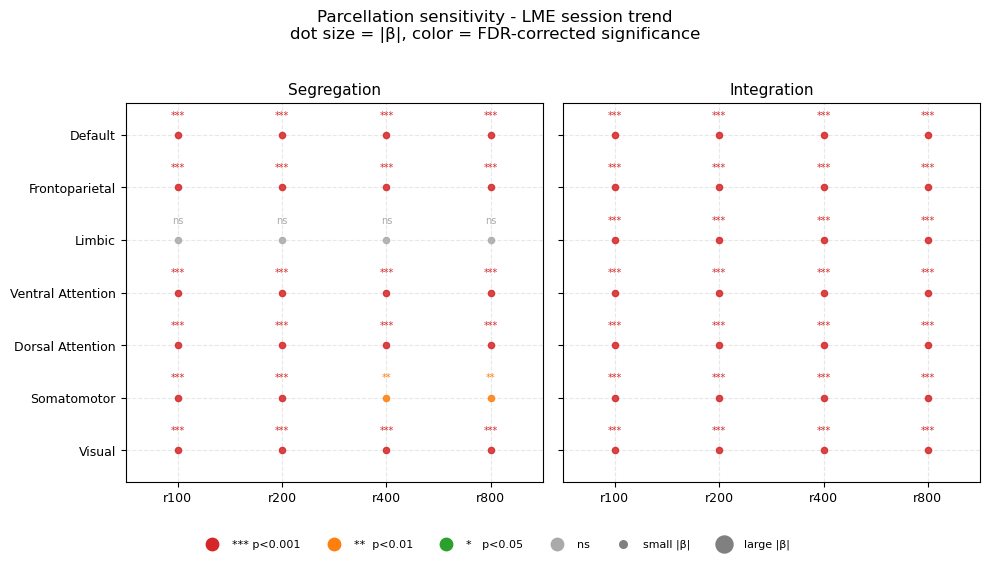

In [24]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

parc_names   = list(PARCELLATIONS.keys())
metric_map   = {
    "segregation":            "Segregation",
    "integration":            "Integration",
}
metrics = list(metric_map.keys())

fig, axes = plt.subplots(1, len(metrics),
                         figsize=(5 * len(metrics), 5),
                         sharey=True)

for ax, metric in zip(axes, metrics):

    for j, p_name in enumerate(parc_names):
        stats_df = parc_results[p_name]["stats_df"]
        sub      = stats_df[stats_df["metric"] == metric].copy()

        for i, net_name in enumerate(YEO_NAMES):
            row = sub[sub["net_name"] == net_name]
            if row.empty:
                continue

            beta   = float(row["beta"].iloc[0])
            p_corr = float(row["p_corr"].iloc[0])
            stars  = sig_stars(p_corr)

            # color by significance, size by |beta|
            color = (
                "#d62728" if p_corr < 0.001 else
                "#ff7f0e" if p_corr < 0.01  else
                "#2ca02c" if p_corr < 0.05  else
                "#aaaaaa"
            )
            size = max(20, abs(beta) * 3000)  # scale to visible range

            ax.scatter(j, i, s=size, color=color,
                       alpha=0.85, zorder=2)
            ax.text(j, i + 0.28, stars,
                    ha="center", va="bottom",
                    fontsize=7, color=color)

    ax.set_xticks(range(len(parc_names)))
    ax.set_xticklabels(parc_names, fontsize=9)
    ax.set_yticks(range(len(YEO_NAMES)))
    ax.set_yticklabels(YEO_NAMES, fontsize=9)
    ax.set_title(metric_map[metric], fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.3, zorder=1)
    ax.set_xlim(-0.5, len(parc_names) - 0.5)
    ax.set_ylim(-0.6, len(YEO_NAMES) - 0.4)

# shared legend
legend_elements = [
    plt.scatter([], [], s=80, color="#d62728", label="*** p<0.001"),
    plt.scatter([], [], s=80, color="#ff7f0e", label="**  p<0.01"),
    plt.scatter([], [], s=80, color="#2ca02c", label="*   p<0.05"),
    plt.scatter([], [], s=80, color="#aaaaaa", label="ns"),
    plt.scatter([], [], s=30,  color="gray",    label="small |β|"),
    plt.scatter([], [], s=150, color="gray",    label="large |β|"),
]
fig.legend(handles=legend_elements,
           loc="lower center", ncol=6,
           fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle(
    "Parcellation sensitivity - LME session trend\n"
    "dot size = |β|, color = FDR-corrected significance",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "parcellation_sensitivity.png"), dpi =600,
            bbox_inches="tight")
plt.show()

In [25]:
# Before the plotting loop
all_beta = []

for metric in metrics:
    for p_name in parc_names:
        stats_df = parc_results[p_name]["stats_df"]
        sub = stats_df[stats_df["metric"] == metric]
        all_beta.extend(sub["beta"].values)

all_beta = np.array(all_beta, dtype=float)
beta_range = np.nanmax(np.abs(all_beta))

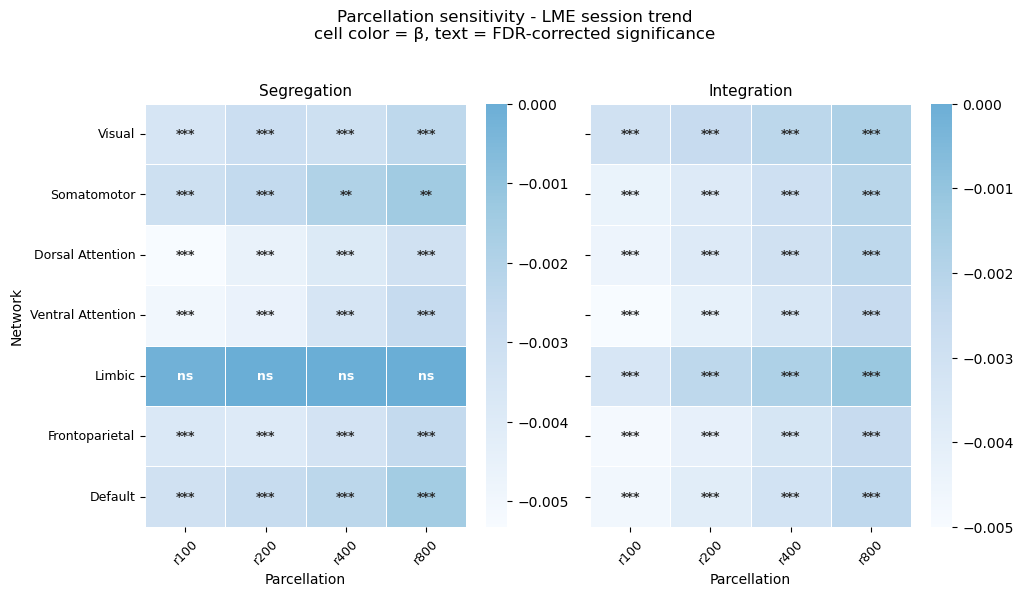

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

parc_names = list(PARCELLATIONS.keys())
metric_map = {
    "segregation": "Segregation",
    "integration": "Integration",
}
metrics = list(metric_map.keys())

fig, axes = plt.subplots(
    1, len(metrics),
    figsize=(5.2 * len(metrics), 5.8),
    sharey=True
)

if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    beta_mat = np.full((len(YEO_NAMES), len(parc_names)), np.nan)
    annot_mat = np.full((len(YEO_NAMES), len(parc_names)), "", dtype=object)

    for j, p_name in enumerate(parc_names):
        stats_df = parc_results[p_name]["stats_df"]
        sub = stats_df[stats_df["metric"] == metric].copy()

        for i, net_name in enumerate(YEO_NAMES):
            row = sub[sub["net_name"] == net_name]
            if row.empty:
                continue

            beta = float(row["beta"].iloc[0])
            p_corr = float(row["p_corr"].iloc[0])

            beta_mat[i, j] = beta
            annot_mat[i, j] = sig_stars(p_corr)



    vmin = np.nanmin(beta_mat)   # most negative β
    vmax = 0.0

    sns.heatmap(
        beta_mat,
        ax=ax,
        cmap="Blues",
        center=0,
        vmin=vmin,
        vmax=vmax,
        annot=annot_mat,
        fmt="",
        annot_kws={"fontsize": 9, "fontweight": "bold"},
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        xticklabels=parc_names,
        yticklabels=YEO_NAMES
    )

    ax.set_title(metric_map[metric], fontsize=11)
    ax.set_xlabel("Parcellation", fontsize=10)
    ax.set_ylabel("Network" if metric == metrics[0] else "", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

fig.suptitle(
    "Parcellation sensitivity - LME session trend\n"
    "cell color = β, text = FDR-corrected significance",
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "parcellation_sensitivity_heatmap.png"), dpi=600, bbox_inches="tight")
plt.show()